# SVM ( Support Vector Machine )

### Step 1: Import Libraries

In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#### Step 2: Load Dataset

In [4]:
df = pd.read_csv(r"D:\4th Semester\Machine Learning by Sir  Abdul Aziz\CSV Datasets\Mobile phone price.csv")
df.head()

,Brand,Model,Storage,RAM,Screen Size (inches),Camera (MP),Battery Capacity (mAh),Price ($)
0,Apple,iPhone 13 Pro,128 GB,6 GB,6.1,12 + 12 + 12,3095,999
1,Samsung,Galaxy S21 Ultra,256 GB,12 GB,6.8,108 + 10 + 10 + 12,5000,1199
2,OnePlus,9 Pro,128 GB,8 GB,6.7,48 + 50 + 8 + 2,4500,899
3,Xiaomi,Redmi Note 10 Pro,128 GB,6 GB,6.67,64 + 8 + 5 + 2,5020,279
4,Google,Pixel 6,128 GB,8 GB,6.4,50 + 12.2,4614,799


### Step 3: Exploratory Data Analysis

In [5]:
# Total Numbers of row & columns
df.shape

(407, 8)

In [6]:
# Information about dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Brand                   407 non-null    str  
 1   Model                   407 non-null    str  
 2   Storage                 407 non-null    str  
 3   RAM                     407 non-null    str  
 4   Screen Size (inches)    407 non-null    str  
 5   Camera (MP)             407 non-null    str  
 6   Battery Capacity (mAh)  407 non-null    int64
 7   Price ($)               407 non-null    str  
dtypes: int64(1), str(7)
memory usage: 25.6 KB


In [7]:
# Checking the Missing values
df.isnull().sum()

Brand                     0
Model                     0
Storage                   0
RAM                       0
Screen Size (inches)      0
Camera (MP)               0
Battery Capacity (mAh)    0
Price ($)                 0
dtype: int64

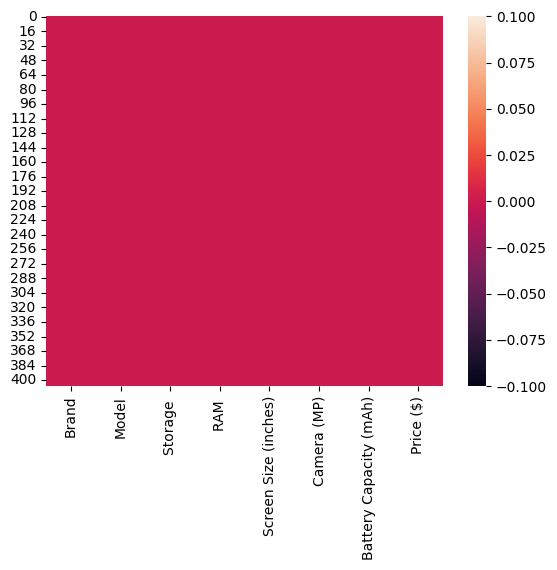

In [8]:
# Graph to clearly see Missing values
sns.heatmap(df.isnull())
plt.show()

In [9]:
# Check for Duplicate Values
df.duplicated().sum()

np.int64(26)

In [10]:
df[df.duplicated()==True]

,Brand,Model,Storage,RAM,Screen Size (inches),Camera (MP),Battery Capacity (mAh),Price ($)
45,Apple,iPhone 12 Mini,64 GB,4 GB,5.4,12 + 12,2227,699
61,Xiaomi,Poco M3 Pro 5G,64 GB,4 GB,6.5,48 + 2 + 2,5000,199
132,Nokia,XR20,128GB,6GB,6.67,48MP + 13MP,4630,$549
170,Motorola,Moto G Stylus 5G,128GB,5GB,6.8,48MP + 8MP + 5MP,5000,$399
195,Oppo,A74 5G,128GB,6GB,6.5,48MP + 2MP + 2MP,5000,$299
221,Vivo,Y12s,32GB,3GB,6.51,13MP + 2MP,5000,$149
229,Xiaomi,Redmi Note 10 Pro Max,128GB,8GB,6.67,108MP + 8MP + 5MP + 2MP,5020,$329
240,Nokia,C20 Plus,32GB,3GB,6.5,8MP + 2MP,4950,$99
246,Xiaomi,Poco X3 Pro,128GB,6GB,6.67,48MP + 8MP + 2MP + 2MP,5160,$249
248,Oppo,A16,32GB,3GB,6.52,13MP + 2MP + 2MP,5000,$149


### Don't Remove duplicate values as they are only same in two features

### Step 4: Encoding of Dataset

In [11]:
# Unique Values
df['Brand'].unique()

<StringArray>
[     'Apple',    'Samsung',    'OnePlus',     'Xiaomi',     'Google',
       'Oppo',       'Vivo',     'Realme',   'Motorola',      'Nokia',
       'Sony',         'LG',       'Asus', 'Blackberry',        'CAT',
     'Huawei']
Length: 16, dtype: str

In [12]:
# Count Values
df["Brand"].value_counts()

Brand
Samsung       79
Xiaomi        67
Oppo          56
Realme        43
Vivo          35
Apple         30
Nokia         28
Motorola      23
OnePlus       15
Huawei        12
Google         7
Asus           4
LG             3
Blackberry     3
Sony           1
CAT            1
Name: count, dtype: int64

In [13]:
# Unique Values
df['Model'].unique()

<StringArray>
[    'iPhone 13 Pro',  'Galaxy S21 Ultra',             '9 Pro',
 'Redmi Note 10 Pro',           'Pixel 6',         'iPhone 13',
    'Galaxy Z Flip3',       'Poco X3 Pro',     'Reno6 Pro+ 5G',
          'X70 Pro+',
 ...
          'Redmi 9C',               'Y7p',     'iPhone 12 Pro',
                 '7',               'A93',        'Moto G Pro',
          'P30 Lite',     'Mi 10 Lite 5G', 'iPhone 12 Pro Max',
             'Reno3']
Length: 239, dtype: str

In [14]:
# Count Values
df["Model"].value_counts()

Model
Poco X3 Pro          6
Redmi 10 Prime       5
Y33s                 5
iPhone XR            5
C21Y                 5
                    ..
Moto G Pro           1
P30 Lite             1
Mi 10 Lite 5G        1
iPhone 12 Pro Max    1
Reno3                1
Name: count, Length: 239, dtype: int64

In [15]:
# Apply Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Brand"] = le.fit_transform(df["Brand"])
df["Model"] = le.fit_transform(df["Model"])

In [16]:
df.head()

,Brand,Model,Storage,RAM,Screen Size (inches),Camera (MP),Battery Capacity (mAh),Price ($)
0,0,232,128 GB,6 GB,6.1,12 + 12 + 12,3095,999
1,12,100,256 GB,12 GB,6.8,108 + 10 + 10 + 12,5000,1199
2,9,19,128 GB,8 GB,6.7,48 + 50 + 8 + 2,4500,899
3,15,178,128 GB,6 GB,6.67,64 + 8 + 5 + 2,5020,279
4,4,162,128 GB,8 GB,6.4,50 + 12.2,4614,799


In [17]:
# Drop 'Camera (MP)' because it will create Problems
df.drop(columns=['Camera (MP)'],inplace=True)

In [18]:
df.head()

,Brand,Model,Storage,RAM,Screen Size (inches),Battery Capacity (mAh),Price ($)
0,0,232,128 GB,6 GB,6.1,3095,999
1,12,100,256 GB,12 GB,6.8,5000,1199
2,9,19,128 GB,8 GB,6.7,4500,899
3,15,178,128 GB,6 GB,6.67,5020,279
4,4,162,128 GB,8 GB,6.4,4614,799


In [19]:
df['RAM ']=df['RAM '].str.replace("GB","")
df['Storage ']=df['Storage '].str.replace("GB","")

In [20]:
df.head()

,Brand,Model,Storage,RAM,Screen Size (inches),Battery Capacity (mAh),Price ($)
0,0,232,128,6,6.1,3095,999
1,12,100,256,12,6.8,5000,1199
2,9,19,128,8,6.7,4500,899
3,15,178,128,6,6.67,5020,279
4,4,162,128,8,6.4,4614,799


In [21]:
df['Screen Size (inches)'].unique()

<StringArray>
[           '6.1',            '6.8',            '6.7',           '6.67',
            '6.4',           '6.55',           '6.78',           '6.43',
            '6.5',           '6.62',            '5.4',            '6.2',
           '6.51',            '6.6',            '4.7',           '6.58',
           '6.52',           '6.44',           '6.53',           '6.56',
      '6.8 + 3.9',            '4.5',           '6.39',            '5.9',
            '5.5',           '6.81',           '5.99',           '6.82',
            '6.3',           '6.22',              '6',           '6.35',
            '6.9',           '6.76',           '6.49',           '6.72',
            '5.7',           '6.47', '7.6 (unfolded)',           '6.15',
           '6.57']
Length: 41, dtype: str

In [22]:
# Replace Values
df['Screen Size (inches)'] = df['Screen Size (inches)'].str.replace("6.8 + 3.9","6.8")
df['Screen Size (inches)'] = df['Screen Size (inches)'].str.replace("7.6 (unfolded)","7.6")

In [23]:
df['Screen Size (inches)'].unique()

<StringArray>
[ '6.1',  '6.8',  '6.7', '6.67',  '6.4', '6.55', '6.78', '6.43',  '6.5',
 '6.62',  '5.4',  '6.2', '6.51',  '6.6',  '4.7', '6.58', '6.52', '6.44',
 '6.53', '6.56',  '4.5', '6.39',  '5.9',  '5.5', '6.81', '5.99', '6.82',
  '6.3', '6.22',    '6', '6.35',  '6.9', '6.76', '6.49', '6.72',  '5.7',
 '6.47',  '7.6', '6.15', '6.57']
Length: 40, dtype: str

In [24]:
df['Price ($)'].unique()

<StringArray>
[    '999',    '1199',     '899',     '279',     '799',     '249',     '699',
     '329',     '449',     '199',     '299',     '379',     '179',     '729',
     '599',     '139',     '189',     '399',     '259',     '159',     '229',
     '499',     '129',     '529',     '369',    '1099',     '169',      '99',
     '459',     '239',    '1299',     '429',     '659',     '269',     '359',
   '$799 ',   '$399 ',   '$699 ',   '$329 ',   '$999 ',   '$549 ', '$1,299 ',
   '$899 ',   '$449 ',   '$319 ',   '$269 ',   '$349 ',   '$279 ',   '$249 ',
   '$299 ',   '$969 ', '$1,199 ',   '$149 ',   '$139 ',    '$99 ',   '$199 ',
   '$169 ',   '$499 ',   '$179 ',   '$219 ',   '$229 ',   '$239 ',   '$109 ',
   '$189 ',   '$389 ',   '$309 ',   '$369 ',   '$129 ',   '$849 ',   '$469 ',
   '$209 ',   '$119 ',   '$339 ',   '$429 ',   '$159 ',   '$379 ',   '$289 ',
     '130',     '749',     '149',     '969',     '649',     '349',     '419',
    '1399',    '1999',     '119',     '319',    '1

In [25]:
df['Price ($)'] = df['Price ($)'].str.replace("$","")
df['Price ($)'] = df['Price ($)'].str.replace(",","")

In [26]:
df['Price ($)'].unique()

<StringArray>
[  '999',  '1199',   '899',   '279',   '799',   '249',   '699',   '329',
   '449',   '199',   '299',   '379',   '179',   '729',   '599',   '139',
   '189',   '399',   '259',   '159',   '229',   '499',   '129',   '529',
   '369',  '1099',   '169',    '99',   '459',   '239',  '1299',   '429',
   '659',   '269',   '359',  '799 ',  '399 ',  '699 ',  '329 ',  '999 ',
  '549 ', '1299 ',  '899 ',  '449 ',  '319 ',  '269 ',  '349 ',  '279 ',
  '249 ',  '299 ',  '969 ', '1199 ',  '149 ',  '139 ',   '99 ',  '199 ',
  '169 ',  '499 ',  '179 ',  '219 ',  '229 ',  '239 ',  '109 ',  '189 ',
  '389 ',  '309 ',  '369 ',  '129 ',  '849 ',  '469 ',  '209 ',  '119 ',
  '339 ',  '429 ',  '159 ',  '379 ',  '289 ',   '130',   '749',   '149',
   '969',   '649',   '349',   '419',  '1399',  '1999',   '119',   '319',
  '1049']
Length: 89, dtype: str

In [27]:
# Convert 'Price ($)' to int datatype
df['Price ($)']=df['Price ($)'].astype(int)

In [28]:
# To make classification problem adding a new Column "Category" of price (High = 1 or Low = 0)
median_price = df['Price ($)'].median()
print(f"Median Price: ${median_price}")

df['Category'] = np.where(df['Price ($)'] > median_price,1,0)

Median Price: $299.0


In [29]:
df.head(20)

,Brand,Model,Storage,RAM,Screen Size (inches),Battery Capacity (mAh),Price ($),Category
0,0,232,128,6,6.1,3095,999,1
1,12,100,256,12,6.8,5000,1199,1
2,9,19,128,8,6.7,4500,899,1
3,15,178,128,6,6.67,5020,279,0
4,4,162,128,8,6.4,4614,799,1
5,0,231,128,4,6.1,2815,799,1
6,12,104,256,8,6.7,3300,999,1
7,15,166,128,6,6.67,5160,249,0
8,10,192,128,8,6.55,4500,699,1
9,14,203,256,12,6.78,4500,1199,1


In [30]:
# Check target variable is balance or not.
df['Category'].value_counts()

Category
0    220
1    187
Name: count, dtype: int64

### Step 5: Handling outliers

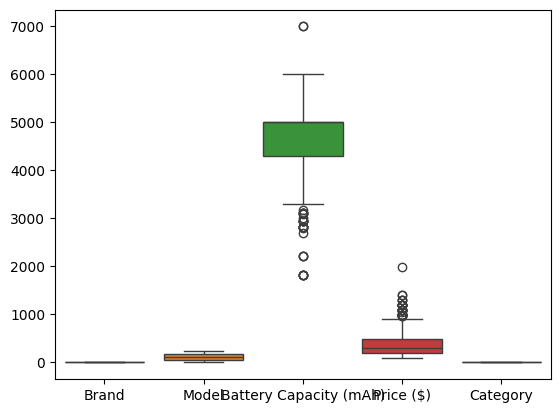

In [31]:
# Checking outliers through graph
sns.boxplot(data=df)
plt.show()

### Step 6: Removing Outliers

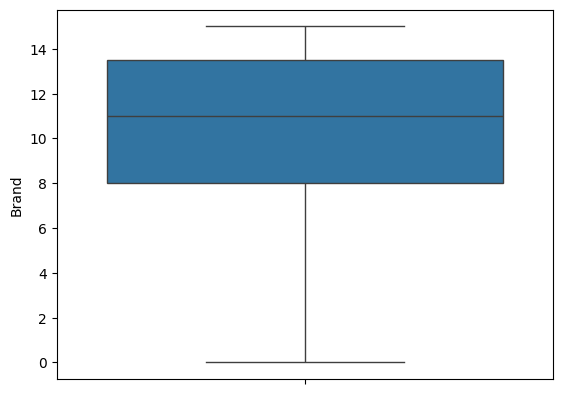

In [32]:
# Checking outliers through graph
sns.boxplot(df['Brand'])
plt.show()

In [33]:
# Remove Outlier in "Brand" Column
q1 = df['Brand'].quantile(0.25)
q3 = df['Brand'].quantile(0.75)
iqr = q3 - q1
min_q = q1-1.5*iqr
max_q = q3+1.5*iqr
df = df[(df['Brand'] <= max_q) & (df['Brand'] >= min_q)]

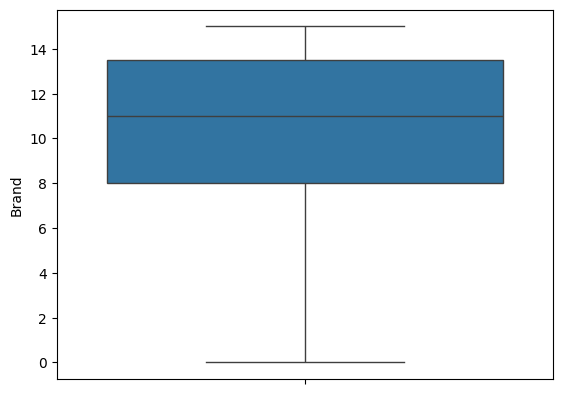

In [34]:
# Checking outliers through graph
sns.boxplot(df['Brand'])
plt.show()

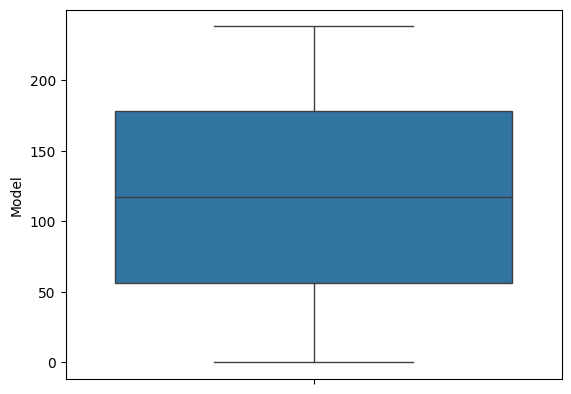

In [35]:
# Checking outliers through graph
sns.boxplot(df['Model'])
plt.show()

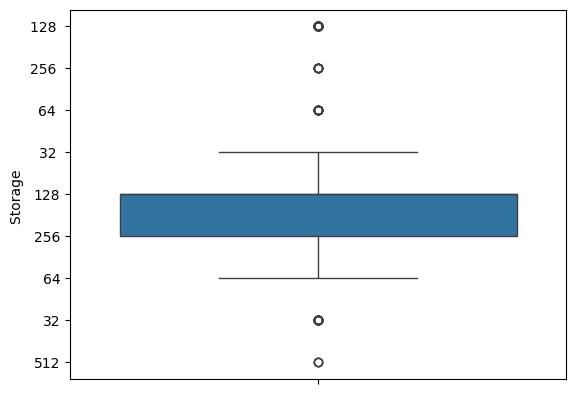

In [36]:
# Checking outliers through graph
sns.boxplot(df['Storage '])
plt.show()

In [37]:
# Remove Outlier in "Storage " Column
q1_s = df['Storage '].astype(int).quantile(0.25)
q3_s = df['Storage '].astype(int).quantile(0.75)
iqr_s = q3_s - q1_s
min_s = q1_s-1.5*iqr_s
max_s = q3_s+1.5*iqr_s
df = df[(df['Storage '].astype(int) <= max_s) & (df['Storage '].astype(int) >= min_s)]

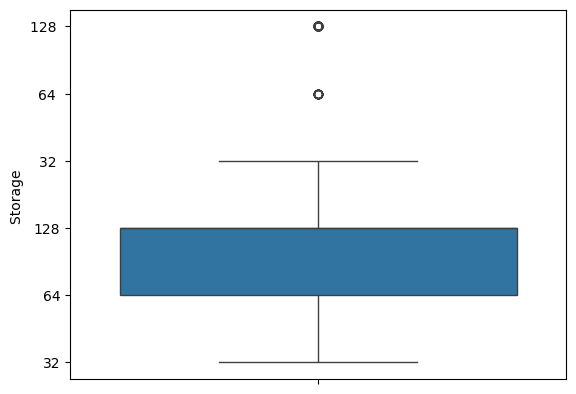

In [38]:
# Checking outliers through graph
sns.boxplot(df['Storage '])
plt.show()

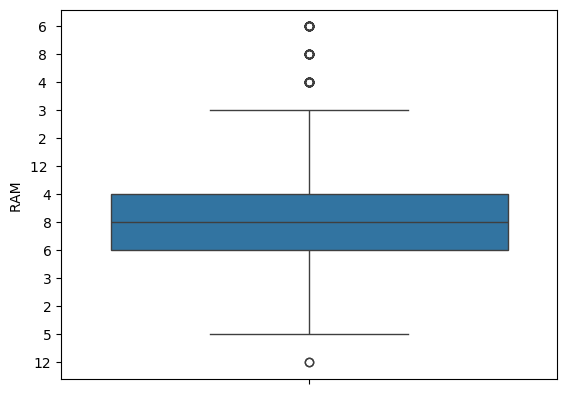

In [39]:
# Checking outliers through graph
sns.boxplot(df['RAM '])
plt.show()

In [40]:
# Remove Outlier in "RAM " Column
q1_r = df['RAM '].astype(int).quantile(0.25)
q3_r = df['RAM '].astype(int).quantile(0.75)
iqr_r = q3_r - q1_r
min_r = q1_r-1.5*iqr_r
max_r = q3_r+1.5*iqr_r
df = df[(df['RAM '].astype(int) <= max_r) & (df['RAM '].astype(int) >= min_r)]

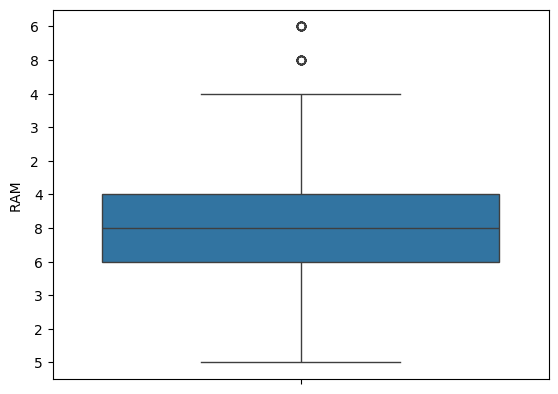

In [41]:
# Checking outliers through graph
sns.boxplot(df['RAM '])
plt.show()

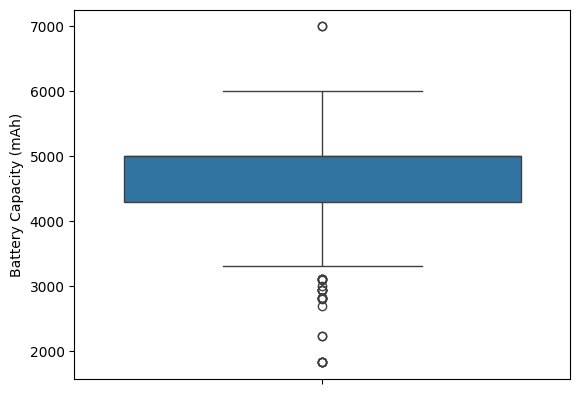

In [42]:
# Checking outliers through graph
sns.boxplot(df['Battery Capacity (mAh)'])
plt.show()

In [43]:
# Remove Outlier in "Battery Capacity (mAh)" Column
q1_b = df['Battery Capacity (mAh)'].quantile(0.25)
q3_b = df['Battery Capacity (mAh)'].quantile(0.75)
iqr_b = q3_b - q1_b
min_b = q1_b-1.5*iqr_b
max_b = q3_b+1.5*iqr_b
df = df[(df['Battery Capacity (mAh)'] <= max_b) & (df['Battery Capacity (mAh)'] >= min_b)]

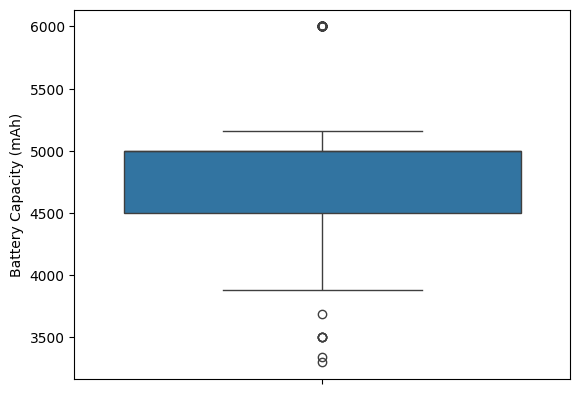

In [44]:
# Checking outliers through graph
sns.boxplot(df['Battery Capacity (mAh)'])
plt.show()

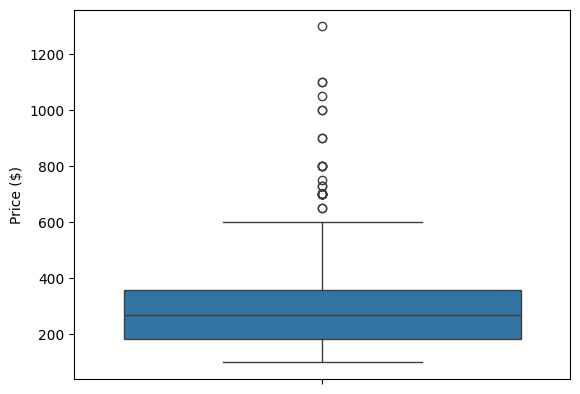

In [45]:
# Checking outliers through graph
sns.boxplot(df['Price ($)'])
plt.show()

In [46]:
# Remove Outlier in "Price ($)" Column
q1_p = df['Price ($)'].quantile(0.25)
q3_p = df['Price ($)'].quantile(0.75)
iqr_p = q3_p - q1_p
min_p = q1_p-1.5*iqr_p
max_p = q3_p+1.5*iqr_p
df = df[(df['Price ($)'] <= max_p) & (df['Price ($)'] >= min_p)]

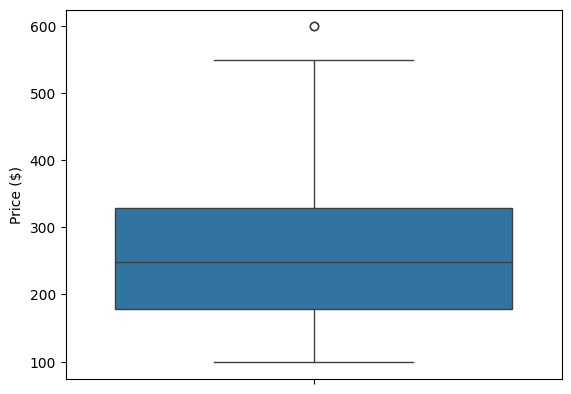

In [47]:
# Checking outliers through graph
sns.boxplot(df['Price ($)'])
plt.show()

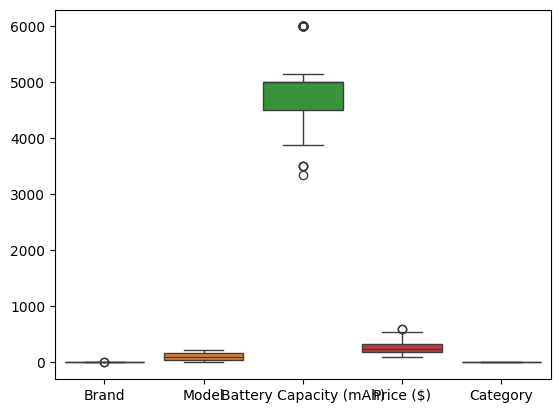

In [48]:
# Checking outliers through graph
sns.boxplot(df)
plt.show()

### Step 7: Normalization

In [49]:
df.info()

<class 'pandas.DataFrame'>
Index: 306 entries, 3 to 405
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Brand                   306 non-null    int64
 1   Model                   306 non-null    int64
 2   Storage                 306 non-null    str  
 3   RAM                     306 non-null    str  
 4   Screen Size (inches)    306 non-null    str  
 5   Battery Capacity (mAh)  306 non-null    int64
 6   Price ($)               306 non-null    int64
 7   Category                306 non-null    int64
dtypes: int64(5), str(3)
memory usage: 21.5 KB


In [50]:
# Balance the Features for better results
from sklearn.preprocessing import MinMaxScaler
m = MinMaxScaler()
for i in df.columns:
         df[i] = m.fit_transform(df[[i]])

In [51]:
df.head()

,Brand,Model,Storage,RAM,Screen Size (inches),Battery Capacity (mAh),Price ($),Category
3,1.000000,0.805430,1.0,0.666667,0.886364,0.631579,0.36,0.0
7,1.000000,0.751131,1.0,0.666667,0.886364,0.684211,0.30,0.0
10,0.538462,0.678733,1.0,0.666667,0.704545,0.436090,0.46,1.0
11,0.769231,0.357466,1.0,0.666667,0.757576,0.436090,0.70,1.0
12,0.692308,0.285068,1.0,1.000000,0.848485,0.624060,0.46,1.0


### Step 8: Scatter plot

<Axes: >

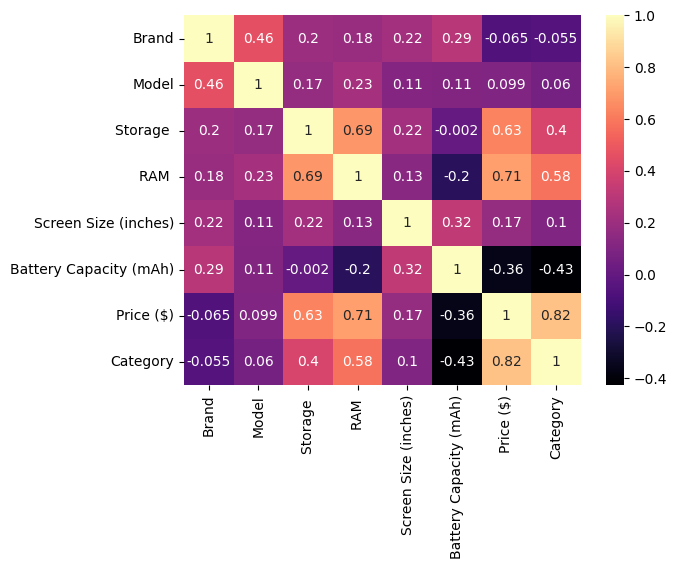

In [52]:
# Checking the Correlations between Features
sns.heatmap(df.corr(),cmap='magma',annot=True)

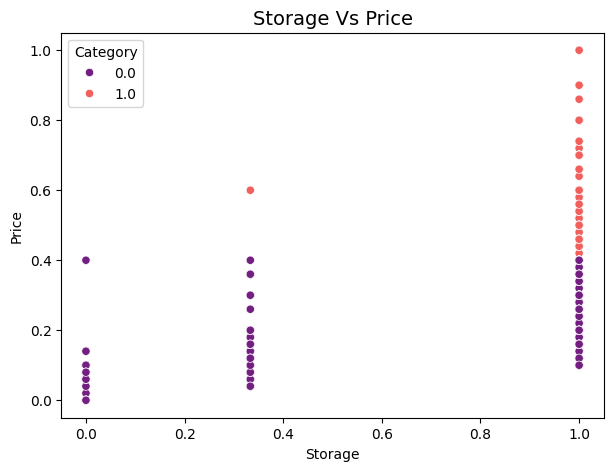

In [53]:
k = df['Storage ']
u = df['Price ($)']
plt.figure(figsize=(7,5))
sns.scatterplot(data=df,x=k,y=u,palette="magma",marker='o',hue='Category')
plt.title("Storage Vs Price", fontsize=14)
plt.xlabel('Storage')
plt.ylabel('Price')
plt.show()

### Step 9: Train/Test Split

In [54]:
df.info()

<class 'pandas.DataFrame'>
Index: 306 entries, 3 to 405
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Brand                   306 non-null    float64
 1   Model                   306 non-null    float64
 2   Storage                 306 non-null    float64
 3   RAM                     306 non-null    float64
 4   Screen Size (inches)    306 non-null    float64
 5   Battery Capacity (mAh)  306 non-null    float64
 6   Price ($)               306 non-null    float64
 7   Category                306 non-null    float64
dtypes: float64(8)
memory usage: 21.5 KB


In [55]:
X = df[['Brand','Model','Storage ','RAM ','Screen Size (inches)','Battery Capacity (mAh)','Price ($)']]
y = df['Category']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Step 10: Apply Model

In [56]:
from sklearn.svm import SVC
c = SVC()
c.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Step 11: Prediction & Accuracy

In [57]:
pred = c.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, pred)*100}")

Accuracy : 98.38709677419355


In [58]:
# Apply Linear kernel
from sklearn.svm import SVC
c = SVC(kernel='linear')
c.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [59]:
# prediction on Linear kernel
pred = c.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, pred)*100}")

Accuracy : 98.38709677419355


In [60]:
# Apply Polynomial kernel
from sklearn.svm import SVC
c = SVC(kernel='poly')
c.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [61]:
# prediction on Linear kernel
pred = c.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, pred)*100}")

Accuracy : 98.38709677419355


In [62]:
# Apply Radial Basis Function kernel
from sklearn.svm import SVC
c = SVC(kernel='rbf')
c.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [63]:
# prediction on Linear kernel
pred = c.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, pred)*100}")

Accuracy : 98.38709677419355


### Step 12: Visualization

In [64]:
# ONLY 2 features use for graph
X2 = df[['Storage ','Price ($)']].values
y2 = df['Category'].values

#Train
model = SVC(kernel='linear')
model.fit(X2,y2)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


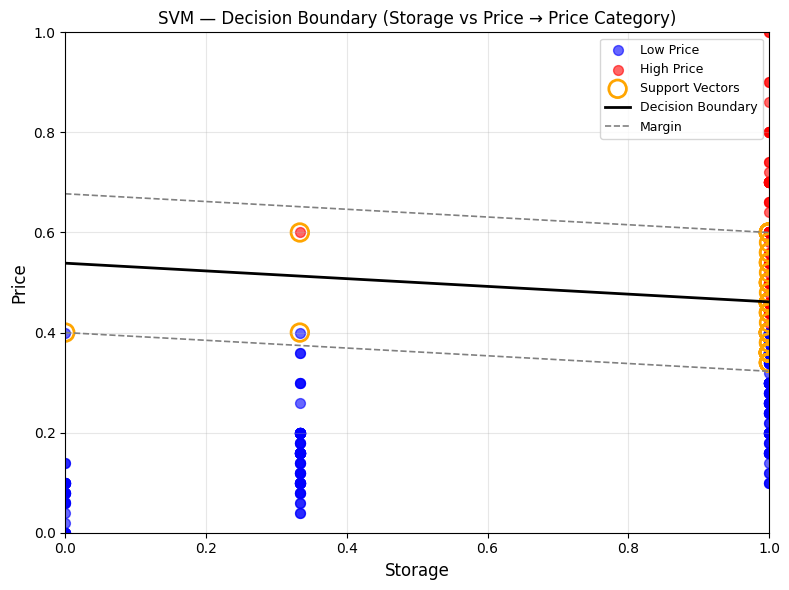

In [67]:
# Plot points
plt.figure(figsize=(8, 6))
plt.scatter(X2[y2==0, 0], X2[y2==0, 1], color="blue", label="Low Price",  s=50, alpha=0.6)
plt.scatter(X2[y2==1, 0], X2[y2==1, 1], color="red",  label="High Price", s=50, alpha=0.6)

# Support Vectors
plt.scatter(model.support_vectors_[:, 0],model.support_vectors_[:, 1],s=160, facecolors="none",edgecolors="orange", linewidths=2,label="Support Vectors")

# SVM line draw karo
w = model.coef_[0]       # weights
b = model.intercept_[0]  # intercept
xx = np.linspace(0, 1, 200)

# Line formula: w[0]*x + w[1]*y + b = 0  =>  y = -(w[0]*x + b) / w[1]
yy      = -(w[0] * xx + b) / w[1]
yy_up   = -(w[0] * xx + b - 1) / w[1]
yy_down = -(w[0] * xx + b + 1) / w[1]

plt.plot(xx, yy,      color="black", lw=2,   label="Decision Boundary")
plt.plot(xx, yy_up,   color="gray",  lw=1.2, ls="--", label="Margin")
plt.plot(xx, yy_down, color="gray",  lw=1.2, ls="--")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("Storage", fontsize=12)
plt.ylabel("Price",     fontsize=12)
plt.title("SVM — Decision Boundary (Storage vs Price → Price Category)", fontsize=12)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## After Many bugs, Finally SVM is completed!!!!!!!!